In [2]:
# creating  and  manipulating a dictionary
student_scores ={
    "Alice":85,
    "Bob":92,
    "charlie":78

}                          
#adding a new entry
student_scores["Diana"] = 95

#Dictionary comprehension: create a new dict with only passing grades(>80)
passing_students = {name:score for name, score in student_scores.items() if score > 80}
print(f"All scores:{student_scores}")
print(f"Passing students: {passing_students}")

All scores:{'Alice': 85, 'Bob': 92, 'charlie': 78, 'Diana': 95}
Passing students: {'Alice': 85, 'Bob': 92, 'Diana': 95}


In [8]:
# Goal: create a list of squares for even numbers between 0 and 9

# Standard way (using loop)
square_loop = []
for x in range(10):
    if x % 2 == 0:
        square_loop.append(x**2)

# List comprehension way
squares_comp = [x**2 for x in range(10) if x % 2 == 0]

print(f"Loop version: {square_loop}")
print(f"Comprehension version: {squares_comp}")

Loop version: [0, 4, 16, 36, 64]
Comprehension version: [0, 4, 16, 36, 64]


In [7]:
import numpy as np

# A Python list
py_list = [1, 2, 3, 4]

# A NumPy array
np_array = np.array([1, 2, 3, 4])

print(f"Python List: {py_list}")
print(f"NumPy Array: {np_array}")

# Example of addition
print("Python List addition:", [1,2] + [3,4])
print("NumPy Array addition:", np.array([1,2]) + np.array([3,4]))

Python List: [1, 2, 3, 4]
NumPy Array: [1 2 3 4]
Python List addition: [1, 2, 3, 4]
NumPy Array addition: [4 6]


In [9]:
import numpy as np
import time

# Generate random temperature data (in Fahrenheit)
raw_data = np.random.uniform(low=-600, high=120, size=1_000_000)

# ----------------------------------------
# APPROACH 1: TRADITIONAL LOOP METHOD
# ----------------------------------------
def process_with_loops(data):
    result = []

    for temp in data:
        # Filter: keep temperatures above absolute zero (-459.67°F)
        if temp > -459.67:
            # Convert Fahrenheit to Celsius
            celsius = (temp - 32) * (5/9)
            result.append(celsius)

    return result


print("Starting loop-based processing...")
start_time = time.time()

loop_output = process_with_loops(raw_data)

loop_duration = time.time() - start_time
print(f"Loop Duration: {loop_duration:.4f} seconds")


# ----------------------------------------
# APPROACH 2: NUMPY VECTORIZATION METHOD
# ----------------------------------------
def process_with_numpy(data):

    # Create mask for valid temperatures
    mask = data > -459.67

    # Filter valid data
    valid_data = data[mask]

    # Convert to Celsius using vectorized operation
    celsius_array = (valid_data - 32) * (5/9)

    return celsius_array


print("\nStarting NumPy vectorized processing...")
start_time = time.time()

numpy_output = process_with_numpy(raw_data)

numpy_duration = time.time() - start_time
print(f"NumPy Duration: {numpy_duration:.4f} seconds")


# ----------------------------------------
# Compare performance
# ----------------------------------------
print("\nPerformance Comparison:")
print(f"Loop Time  : {loop_duration:.4f} seconds")
print(f"NumPy Time : {numpy_duration:.4f} seconds")

speedup = loop_duration / numpy_duration
print(f"Speedup    : {speedup:.2f}x faster using NumPy")

Starting loop-based processing...
Loop Duration: 0.2612 seconds

Starting NumPy vectorized processing...
NumPy Duration: 0.0161 seconds

Performance Comparison:
Loop Time  : 0.2612 seconds
NumPy Time : 0.0161 seconds
Speedup    : 16.23x faster using NumPy


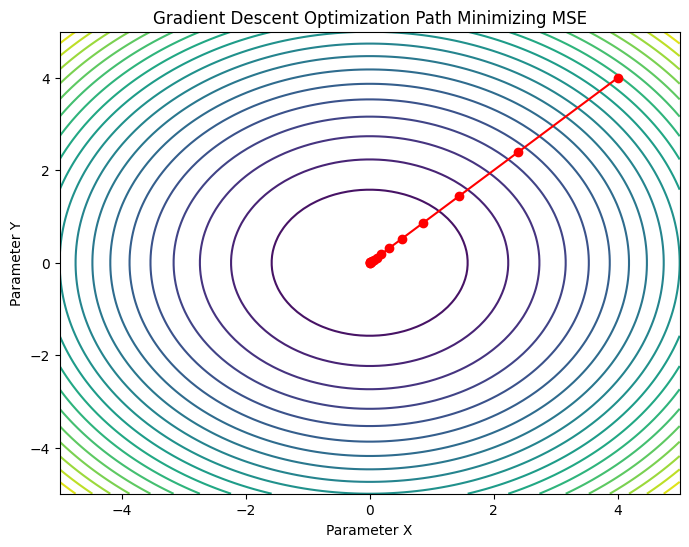

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define MSE loss function (simple quadratic function)
def loss_function(x, y):
    return x**2 + y**2

# Gradient of loss function
def gradient(x, y):
    dx = 2*x
    dy = 2*y
    return dx, dy

# Starting point
x, y = 4, 4

# Learning rate
learning_rate = 0.2

# Store path
x_path = [x]
y_path = [y]

# Gradient descent iterations
for i in range(15):
    dx, dy = gradient(x, y)
    x = x - learning_rate * dx
    y = y - learning_rate * dy
    x_path.append(x)
    y_path.append(y)

# Create contour plot
X = np.linspace(-5, 5, 100)
Y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(X, Y)
Z = loss_function(X, Y)

plt.figure(figsize=(8,6))
plt.contour(X, Y, Z, levels=20)

# Plot optimization path
plt.plot(x_path, y_path, marker='o', color='red')

plt.title("Gradient Descent Optimization Path Minimizing MSE")
plt.xlabel("Parameter X")
plt.ylabel("Parameter Y")

plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

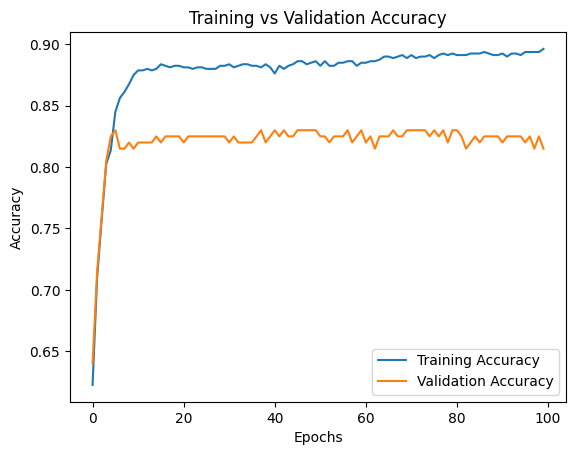

In [7]:
# Simple Training vs Validation Accuracy Code

import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Step 1: Create sample dataset
X, y = make_classification(n_samples=1000, n_features=10, random_state=42)

# Step 2: Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

# Step 3: Create model
model = MLPClassifier(max_iter=1, warm_start=True)

# Step 4: Train model and store accuracy
train_acc = []
val_acc = []

for epoch in range(100):
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    val_acc.append(accuracy_score(y_val, model.predict(X_val)))

# Step 5: Plot graph
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

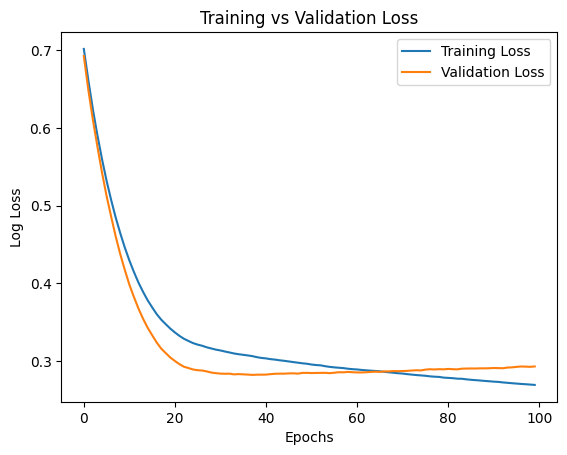

In [8]:
# Simple Training vs Validation Loss Example

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss

# Step 1: Create dataset
X, y = make_classification(n_samples=1000, n_features=10, random_state=42)

# Step 2: Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

# Step 3: Create model
model = MLPClassifier(max_iter=1, warm_start=True)

# Step 4: Train and store loss
train_loss = []
val_loss = []

for epoch in range(100):
    
    model.fit(X_train, y_train)
    
    # Predict probabilities
    train_prob = model.predict_proba(X_train)
    val_prob = model.predict_proba(X_val)
    
    # Calculate log loss
    train_loss.append(log_loss(y_train, train_prob))
    val_loss.append(log_loss(y_val, val_prob))

# Step 5: Plot graph
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")

plt.legend()
plt.show()